# Foreground Simulation

In `meer21cm`, we provide several basic foreground emission templates.
They are meant for visual checks and templates for simulation, and do not incorporate effects such as polarization (and leakages).
Nevertheless, by interfacing with [pysm](https://pysm3.readthedocs.io/en/latest) and [GDSM](https://github.com/telegraphic/pygdsm), the templates should be of reasonable accuracy, ideal for studying foreground removal strategies and running forecasts.

The [ForegroundSimulation class](https://meer21cm.readthedocs.io/en/latest/meer21cm.html#module-meer21cm.fg) handles the simulation. The minimum input is simply `hp_side`, which is the [HEALPix](https://healpy.readthedocs.io/en/latest/) `nside` that gives the angular resolution of the foreground sky map:

In [1]:
import healpy as hp
from meer21cm.fg import ForegroundSimulation
import numpy as np
from meer21cm import PowerSpectrum
from meer21cm.plot import plot_map
from meer21cm.telescope import dish_beam_sigma

In [2]:
fgsim = ForegroundSimulation(
    hp_nside=128,
    backend="haslam", # default is a Haslam 408 MHz map
    sp_indx_for_haslam_backend=-2.0, # default is -2.0
)

The default is just to interpolate the [Haslam map](https://arxiv.org/abs/1411.3628) to any given frequency:

In [3]:
fg_map = fgsim.fg_wcs_cube(np.array([1e9])) # 1 GHz

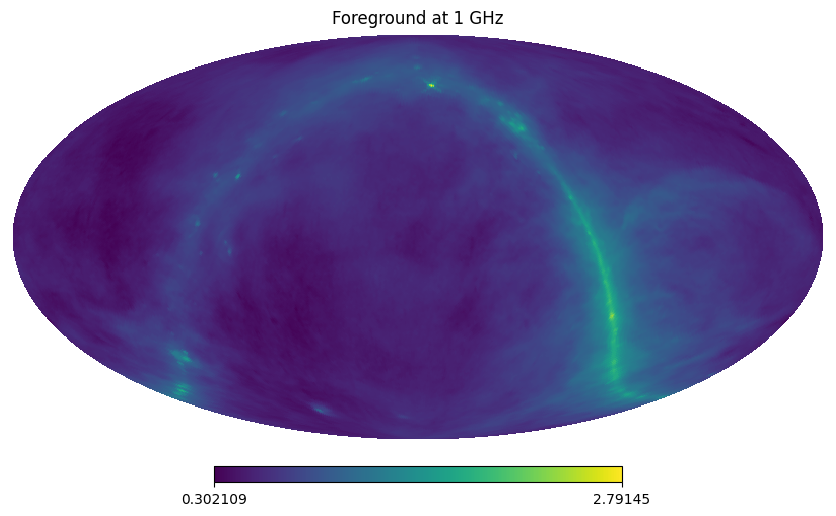

In [4]:
hp.mollview(np.log10(fg_map[0]), title="Foreground at 1 GHz")

The default coordinate system is `C` (Celestial). You can also use `G` (Galactic):

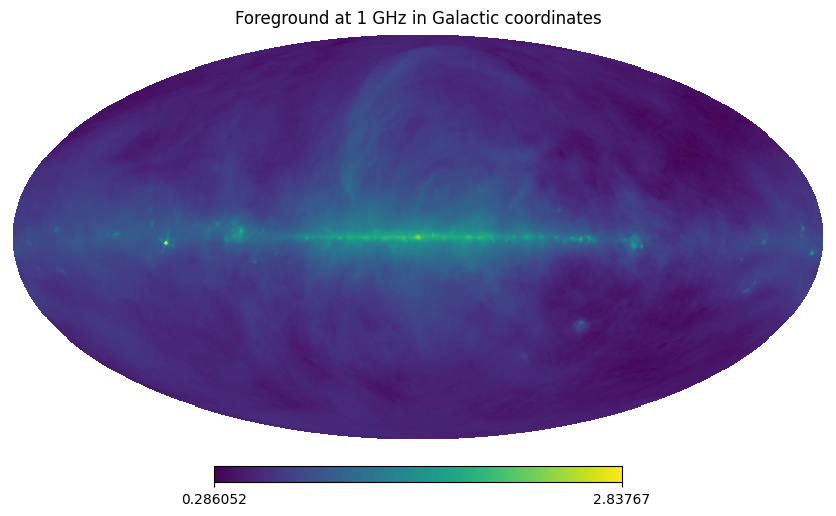

In [5]:
fgsim.coord_system = "G"
fg_map = fgsim.fg_wcs_cube(np.array([1e9])) # 1 GHz
hp.mollview(np.log10(fg_map[0]), title="Foreground at 1 GHz in Galactic coordinates")

For more complicated simulations, you can either use `GDSM` or `PySM3`:

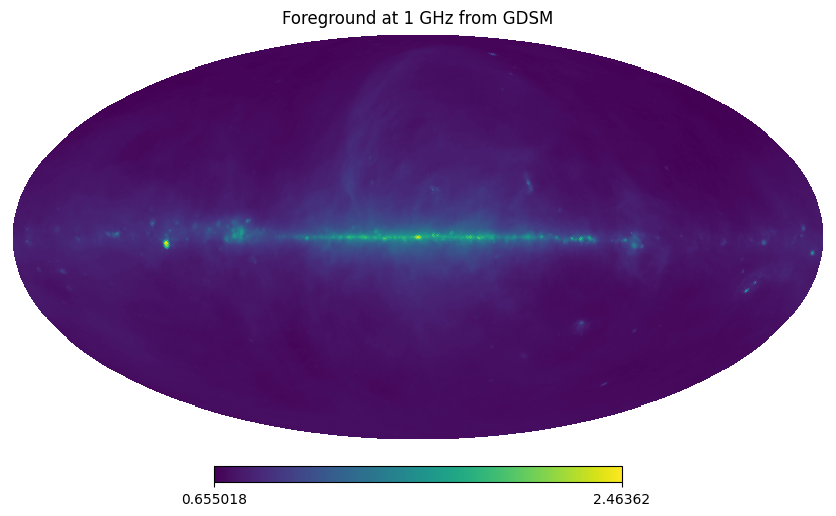

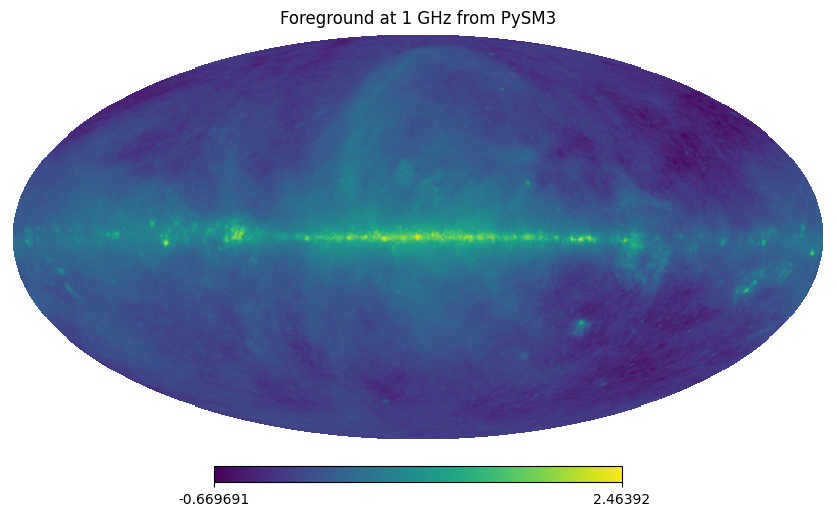

In [6]:
fgsim.backend = "gdsm"
fg_map = fgsim.fg_wcs_cube(np.array([1e9])) # 1 GHz
hp.mollview(np.log10(fg_map[0]), title="Foreground at 1 GHz from GDSM")

fgsim.backend = "pysm"
fg_map = fgsim.fg_wcs_cube(np.array([1e9])) # 1 GHz
hp.mollview(np.log10(fg_map[0]), title="Foreground at 1 GHz from PySM3")

For `pysm`, there is a choice of which component to include, by setting `pysm_preset_strings`. See [pysm documentation](https://pysm3.readthedocs.io/en/latest/models.html) for more information.

Say only a simple synchrotron map:

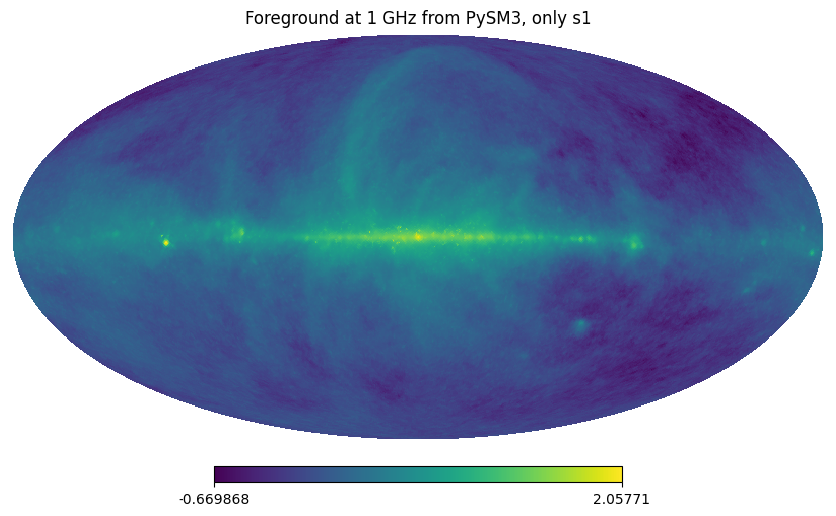

In [7]:
fgsim.pysm_preset_strings = ["s1"]
fg_map = fgsim.fg_wcs_cube(np.array([1e9])) # 1 GHz
hp.mollview(np.log10(fg_map[0]), title="Foreground at 1 GHz from PySM3, only s1")

If you already have a `wcs` survey area specified, you can pass it into `fgsim` and it will automatically project the healpix map onto the wcs grids:

In [8]:
ps = PowerSpectrum(
    survey='meerklass_2021',
    band='L',
)

In [9]:
fgsim.coord_system = 'C'
fgsim.wproj = ps.wproj
fgsim.num_pix_x = ps.num_pix_x
fgsim.num_pix_y = ps.num_pix_y
fg_map = fgsim.fg_wcs_cube(ps.nu) # 1 GHz


The result is the foreground map cube at each frequency:

In [10]:
fg_map.shape

(133, 73, 252)

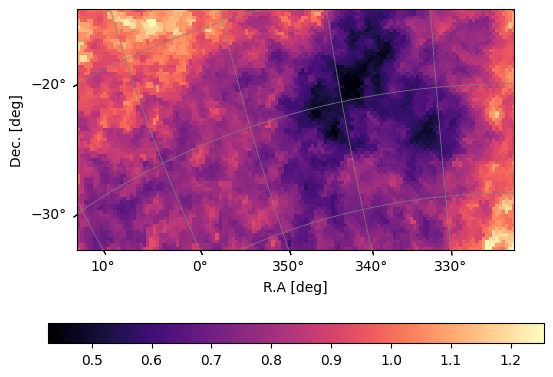

In [11]:
plot_map(fg_map,ps.wproj,)

If you have a beam model you can convolve it with the beam:

In [12]:
ps.sigma_beam_ch = dish_beam_sigma(13.5, ps.nu,)

In [13]:
fg_w_beam,_ = ps.convolve_data(
    ps.beam_image,
    data=fg_map,
    weights=ps.w_HI,
    assign_to_self=False, # do not overwrite ps.data and ps.w_HI
)

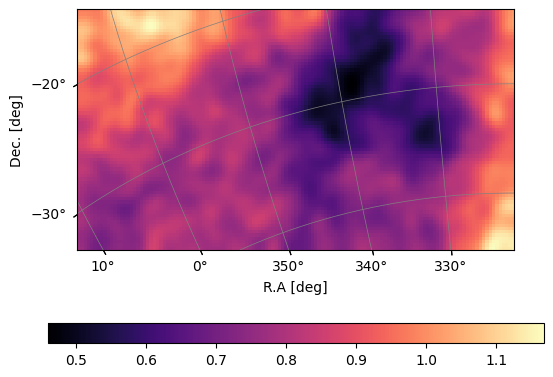

In [14]:
plot_map(fg_w_beam,ps.wproj,)